# AgentGuard Telemetry and Actions Analysis

This notebook analyzes telemetry and actions data from AgentGuard agents (agent-1 through agent-20).
We'll explore field distributions, understand data characteristics, and perform statistical analysis.

## Section 1: Import Required Libraries

Import necessary libraries for data loading, processing, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Section 2: Load Telemetry Data

Load JSONL telemetry data from all agent-{int} folders and combine into a single DataFrame for analysis.

In [2]:
# Define data directory
data_dir = Path(r"c:\Users\zhaoh\Desktop\DL_Proj20\Theory-and-application-of-deep-learning\data\dataset\agentguard-all-batches")

# Load telemetry data from agent-1 through agent-20
telemetry_data = []

for agent_num in range(1, 21):
    agent_dir = data_dir / f"agent-{agent_num}" / "telemetry"
    telemetry_file = agent_dir / "2026-03-15.jsonl"
    
    if telemetry_file.exists():
        print(f"Loading telemetry for agent-{agent_num}...")
        with open(telemetry_file, 'r') as f:
            for line in f:
                try:
                    record = json.loads(line)
                    record['agent_id'] = agent_num
                    telemetry_data.append(record)
                except json.JSONDecodeError:
                    continue
    else:
        print(f"Telemetry file not found for agent-{agent_num}")

# Create DataFrame
df_telemetry = pd.DataFrame(telemetry_data)

print(f"\nTotal telemetry records loaded: {len(df_telemetry)}")
print(f"Agents: {sorted(df_telemetry['agent_id'].unique())}")
print(f"\nTelemetry DataFrame shape: {df_telemetry.shape}")
print(f"\nFirst few records:\n{df_telemetry.head()}")

Loading telemetry for agent-1...
Loading telemetry for agent-2...
Loading telemetry for agent-3...
Loading telemetry for agent-4...
Loading telemetry for agent-5...
Loading telemetry for agent-6...
Loading telemetry for agent-7...
Loading telemetry for agent-8...
Loading telemetry for agent-9...
Loading telemetry for agent-10...
Loading telemetry for agent-11...
Loading telemetry for agent-12...
Loading telemetry for agent-13...
Loading telemetry for agent-14...
Loading telemetry for agent-15...
Loading telemetry for agent-16...
Loading telemetry for agent-17...
Loading telemetry for agent-18...
Loading telemetry for agent-19...
Loading telemetry for agent-20...

Total telemetry records loaded: 40403
Agents: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

Telemetry

## Section 3: Explore Telemetry Fields

Display field descriptions and data types. Explain what each telemetry field represents and its significance.

**Telemetry Field Descriptions:**

- **timestamp**: The Unix timestamp when the telemetry record was captured. Represents the exact time of measurement.
- **jiffies**: System jiffies (CPU clock ticks). Used to measure CPU time and system activity.
- **memory**: Memory usage in bytes. Indicates the amount of RAM consumed by the agent.
- **kb**: Possibly kilobytes of data transferred, disk I/O, or cached memory. Depends on context.
- **agent_id**: Unique identifier for the agent (1-20) that generated the telemetry record.

In [3]:
# Examine telemetry columns and data types
print("Telemetry Columns and Data Types:")
print(f"{'Column':<20} {'Data Type':<15} {'Non-Null Count':<15}")
print("-" * 50)
for col in df_telemetry.columns:
    print(f"{col:<20} {str(df_telemetry[col].dtype):<15} {df_telemetry[col].notna().sum():<15}")

print("\n\nData Type Summary:")
print(df_telemetry.dtypes)

print("\n\nBasic Info:")
print(df_telemetry.info())

Telemetry Columns and Data Types:
Column               Data Type       Non-Null Count 
--------------------------------------------------
timestamp            object          40403          
stream               int64           40403          
cpu                  object          40403          
memory               object          40403          
processes            object          40403          
file_io              object          40403          
network              object          40403          
syscalls             object          40403          
agent_id             int64           40403          


Data Type Summary:
timestamp    object
stream        int64
cpu          object
memory       object
processes    object
file_io      object
network      object
syscalls     object
agent_id      int64
dtype: object


Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40403 entries, 0 to 40402
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ----

## Section 4: Visualize Telemetry Distributions

Create histograms, box plots, and KDE plots for key telemetry fields to understand their distributions.

Numeric columns to visualize: ['stream']


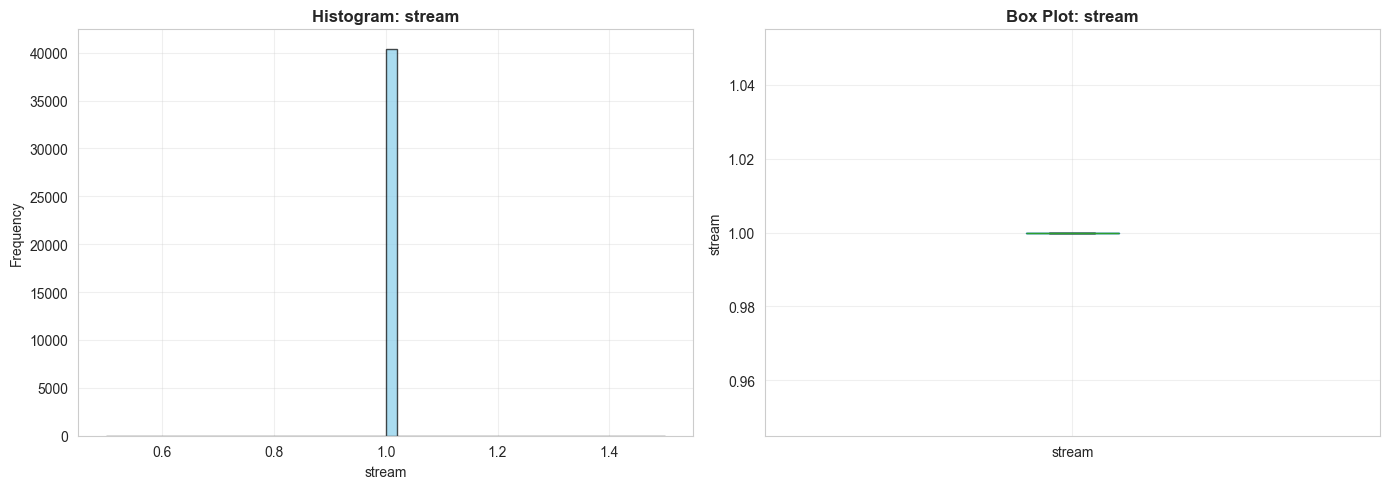

Distributions visualized successfully.


In [4]:
# Identify numeric columns (excluding agent_id for now)
numeric_cols = df_telemetry.select_dtypes(include=[np.number]).columns.tolist()
if 'agent_id' in numeric_cols:
    numeric_cols.remove('agent_id')

print(f"Numeric columns to visualize: {numeric_cols}")

# Create visualizations for each numeric field
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 5*len(numeric_cols)))
if len(numeric_cols) == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(numeric_cols):
    # Histogram
    axes[idx, 0].hist(df_telemetry[col].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'Histogram: {col}', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel(col)
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Box plot
    df_telemetry.boxplot(column=col, ax=axes[idx, 1])
    axes[idx, 1].set_title(f'Box Plot: {col}', fontsize=12, fontweight='bold')
    axes[idx, 1].set_ylabel(col)
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Distributions visualized successfully.")

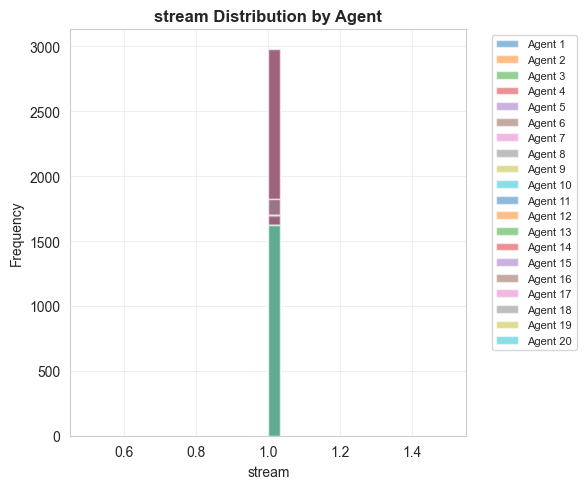

In [5]:
# Distribution comparison across agents
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(6*len(numeric_cols), 5))
if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    for agent in sorted(df_telemetry['agent_id'].unique()):
        agent_data = df_telemetry[df_telemetry['agent_id'] == agent][col]
        axes[idx].hist(agent_data.dropna(), bins=30, alpha=0.5, label=f'Agent {agent}')
    
    axes[idx].set_title(f'{col} Distribution by Agent', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 5: Analyze Telemetry Statistics

Calculate descriptive statistics (mean, median, std, min, max, quantiles) for each telemetry field and identify outliers.

In [6]:
# Calculate descriptive statistics for telemetry
print("=" * 80)
print("TELEMETRY DESCRIPTIVE STATISTICS")
print("=" * 80)

for col in numeric_cols:
    print(f"\n{col.upper()}:")
    print("-" * 40)
    stats = df_telemetry[col].describe()
    print(stats)
    
    # Additional statistics
    print(f"\nPercentiles:")
    percentiles = df_telemetry[col].quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
    for perc, val in percentiles.items():
        print(f"  {perc*100:.0f}%: {val:.2f}")
    
    # Outlier detection using IQR method
    Q1 = df_telemetry[col].quantile(0.25)
    Q3 = df_telemetry[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_telemetry[(df_telemetry[col] < lower_bound) | (df_telemetry[col] > upper_bound)]
    print(f"\nOutliers (IQR method): {len(outliers)} ({len(outliers)/len(df_telemetry)*100:.2f}%)")
    print(f"  Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

# Statistics by agent
print("\n\n" + "=" * 80)
print("TELEMETRY STATISTICS BY AGENT")
print("=" * 80)

for col in numeric_cols:
    print(f"\n{col.upper()} by Agent:")
    print("-" * 60)
    grouped_stats = df_telemetry.groupby('agent_id')[col].agg(['count', 'mean', 'std', 'min', 'max'])
    print(grouped_stats)

TELEMETRY DESCRIPTIVE STATISTICS

STREAM:
----------------------------------------
count    40403.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: stream, dtype: float64

Percentiles:
  25%: 1.00
  50%: 1.00
  75%: 1.00
  90%: 1.00
  95%: 1.00
  99%: 1.00

Outliers (IQR method): 0 (0.00%)
  Lower bound: 1.00, Upper bound: 1.00


TELEMETRY STATISTICS BY AGENT

STREAM by Agent:
------------------------------------------------------------
          count  mean  std  min  max
agent_id                            
1          2980   1.0  0.0    1    1
2          2981   1.0  0.0    1    1
3          2981   1.0  0.0    1    1
4          2982   1.0  0.0    1    1
5          2981   1.0  0.0    1    1
6          1825   1.0  0.0    1    1
7          1826   1.0  0.0    1    1
8          1826   1.0  0.0    1    1
9          1699   1.0  0.0    1    1
10         1699   1.0  0.0    1    1
11         1699   1.0  0.0    1    1
1

## Section 6: Load Actions Data

Load JSONL actions data from all agent-{int} folders and combine into a single DataFrame for analysis.

In [7]:
# Load actions data from agent-1 through agent-20
actions_data = []

for agent_num in range(1, 21):
    agent_dir = data_dir / f"agent-{agent_num}" / "actions"
    actions_file = agent_dir / "2026-03-15.jsonl"
    
    if actions_file.exists():
        print(f"Loading actions for agent-{agent_num}...")
        with open(actions_file, 'r') as f:
            for line in f:
                try:
                    record = json.loads(line)
                    record['agent_id'] = agent_num
                    actions_data.append(record)
                except json.JSONDecodeError:
                    continue
    else:
        print(f"Actions file not found for agent-{agent_num}")

# Create DataFrame
df_actions = pd.DataFrame(actions_data)

print(f"\nTotal actions records loaded: {len(df_actions)}")
print(f"Agents: {sorted(df_actions['agent_id'].unique())}")
print(f"\nActions DataFrame shape: {df_actions.shape}")
print(f"\nFirst few records:\n{df_actions.head()}")

Loading actions for agent-1...
Loading actions for agent-2...
Loading actions for agent-3...
Loading actions for agent-4...
Loading actions for agent-5...
Loading actions for agent-6...
Loading actions for agent-7...
Loading actions for agent-8...
Loading actions for agent-9...
Loading actions for agent-10...
Loading actions for agent-11...
Loading actions for agent-12...
Loading actions for agent-13...
Loading actions for agent-14...
Loading actions for agent-15...
Loading actions for agent-16...
Loading actions for agent-17...
Loading actions for agent-18...
Loading actions for agent-19...
Loading actions for agent-20...

Total actions records loaded: 69210
Agents: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

Actions DataFrame shape: (69210, 19)

First few rec

## Section 7: Explore Actions Fields

Display field descriptions and data types. Explain what each actions field represents and its significance to agent behavior.

**Actions Field Descriptions:**

The actions data captures the behaviors and decisions made by agents. Common fields in actions typically include:

- **timestamp**: Unix timestamp when the action was performed.
- **action_type**: Type of action performed by the agent (e.g., 'move', 'attack', 'defend', 'interact', etc.).
- **target**: Identifier of the target entity or coordinates for the action.
- **actor**: The agent performing the action.
- **success**: Boolean indicating whether the action was successfully executed.
- **duration**: Time taken to execute the action.
- **parameters**: Additional parameters specific to the action type.
- **agent_id**: Unique identifier for the agent (1-20) that performed the action.

In [8]:
# Examine actions columns and data types
print("Actions Columns and Data Types:")
print(f"{'Column':<20} {'Data Type':<15} {'Non-Null Count':<15}")
print("-" * 50)
for col in df_actions.columns:
    print(f"{col:<20} {str(df_actions[col].dtype):<15} {df_actions[col].notna().sum():<15}")

print("\n\nData Type Summary:")
print(df_actions.dtypes)

print("\n\nBasic Info:")
print(df_actions.info())

print("\n\nSample of Actions Data:")
print(df_actions.head(10))

Actions Columns and Data Types:
Column               Data Type       Non-Null Count 
--------------------------------------------------
timestamp            object          69210          
stream               int64           69210          
agent_id             int64           69210          
event                object          69210          
content_hash         object          48505          
user_initiated       object          52221          
source               object          52221          
tokens_in            float64         7915           
tokens_out           float64         7915           
model                object          7915           
latency              float64         14310          
has_tool_calls       object          7915           
tool                 object          12790          
args_hash            object          6395           
prev_action          object          3635           
tool_call_id         object          6395           
result_hash     

## Section 8: Visualize Actions Distributions

Create visualizations for actions fields using appropriate chart types to show distributions and patterns.

Numeric columns in actions: ['tokens_in', 'tokens_out', 'latency', 'result_length', 'turn']
Categorical columns in actions: ['timestamp', 'event', 'content_hash', 'user_initiated', 'source', 'model', 'has_tool_calls', 'tool', 'args_hash', 'prev_action', 'tool_call_id', 'result_hash']


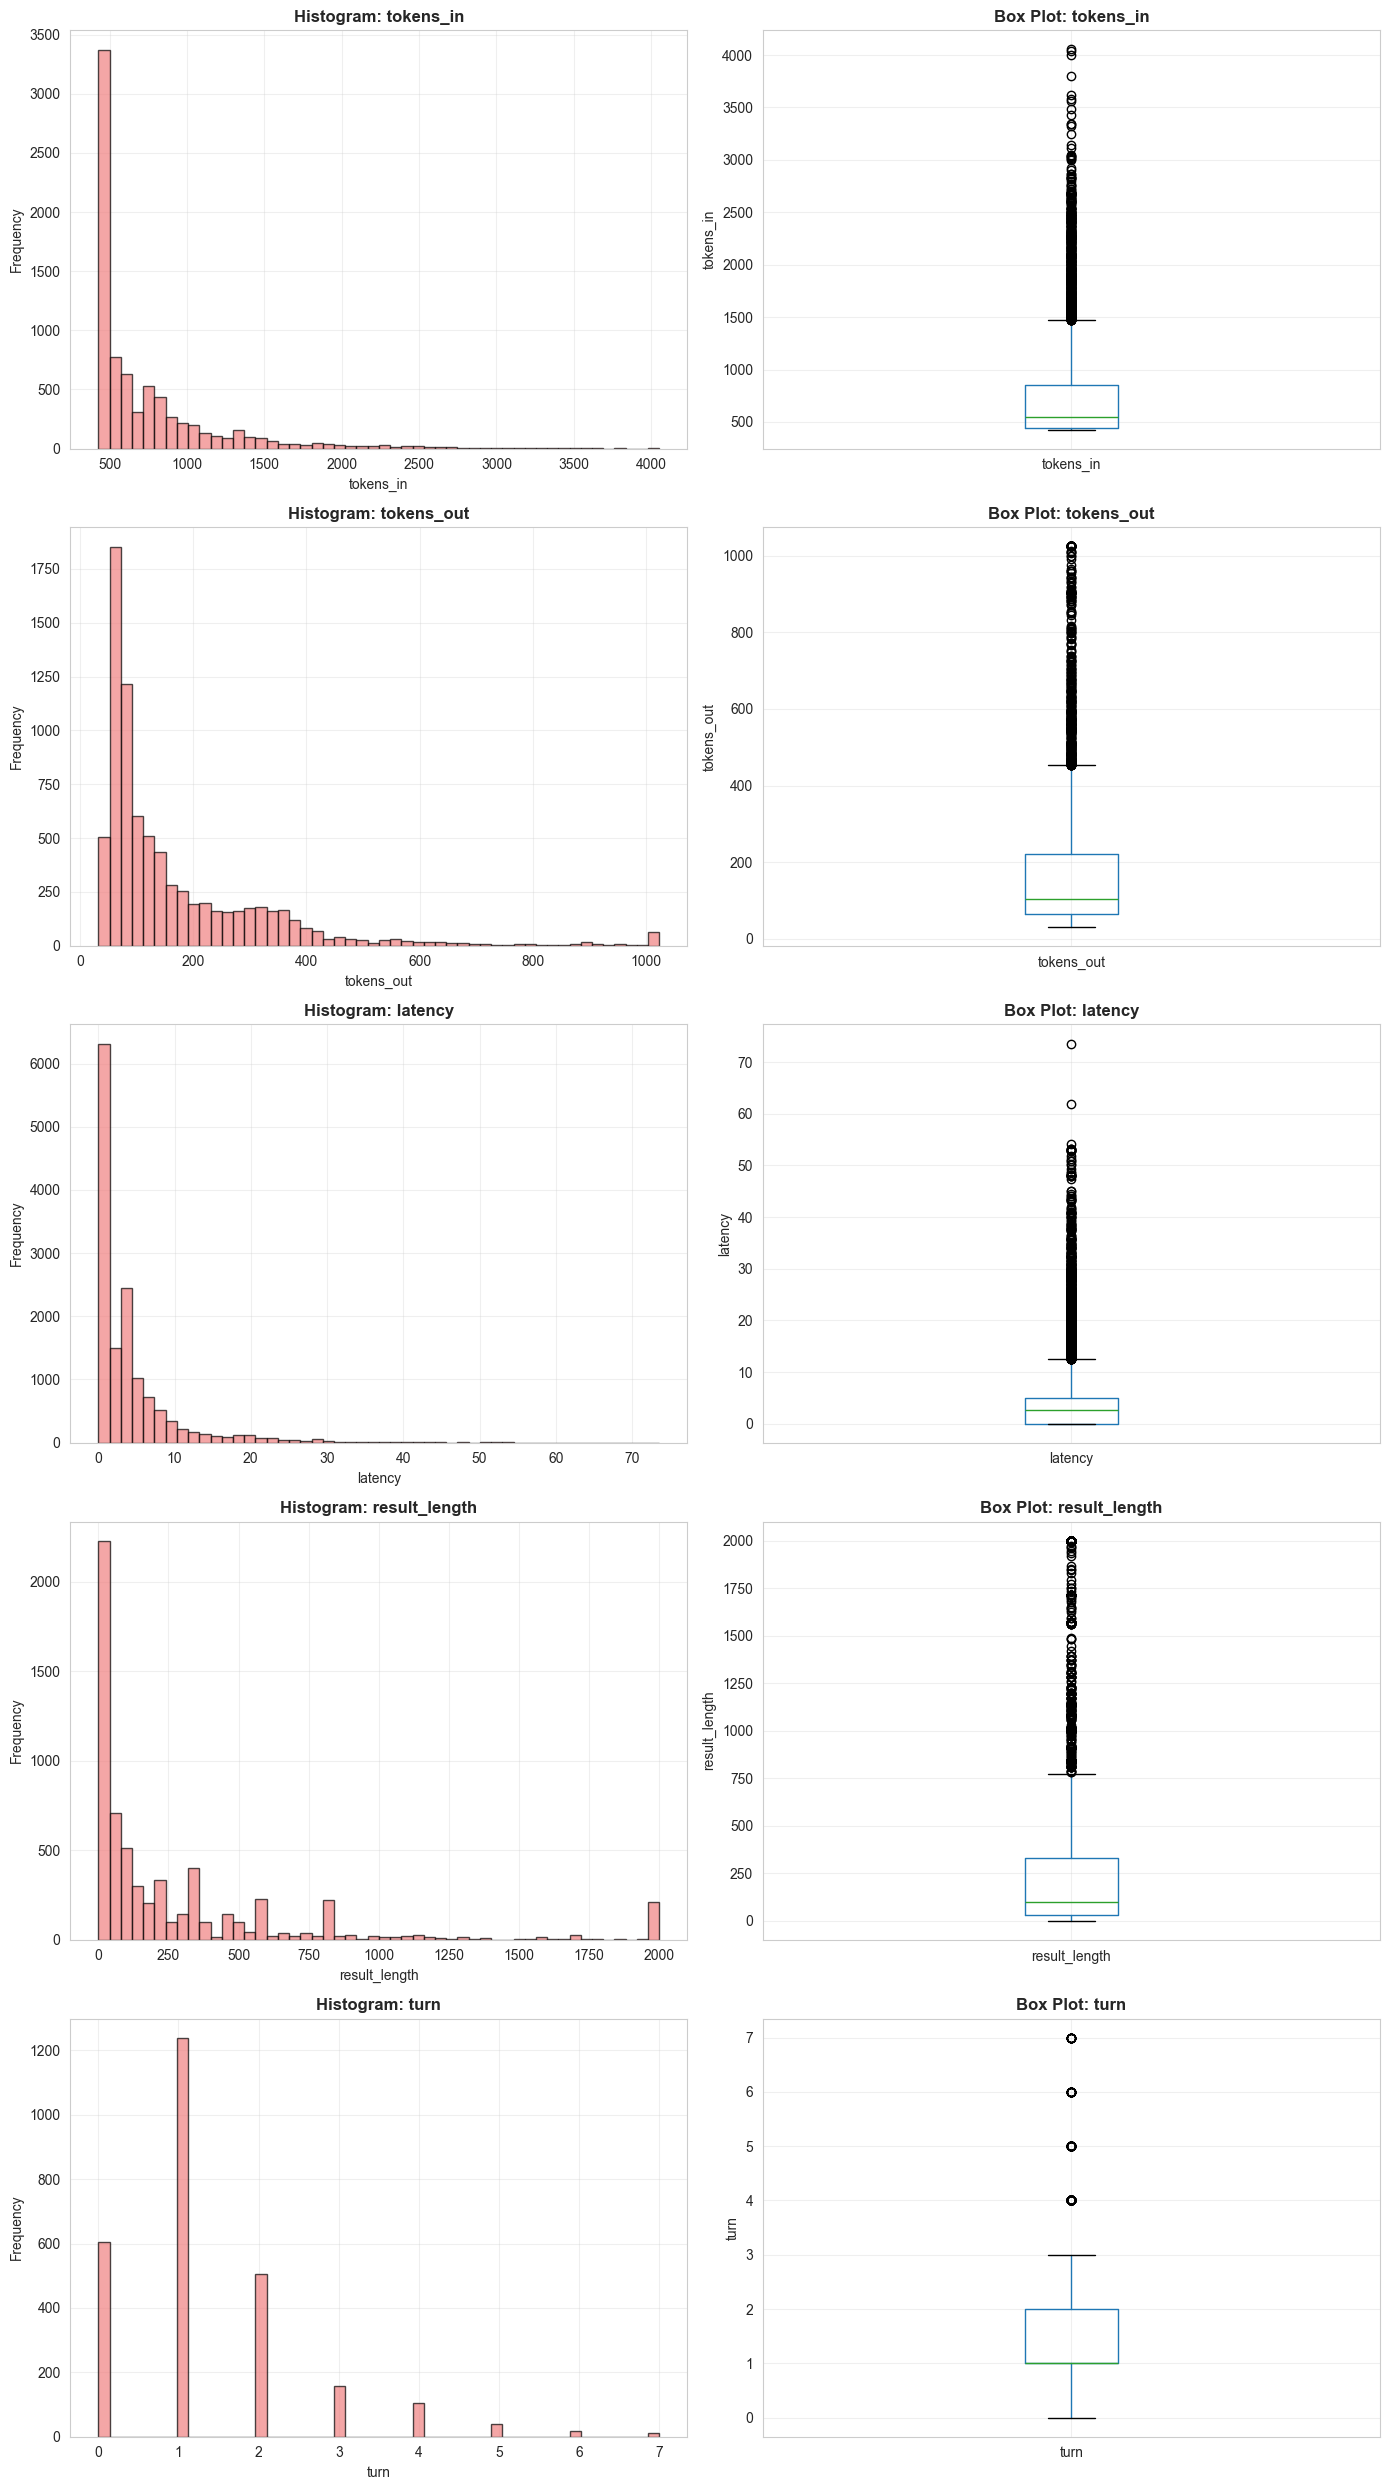


timestamp: Too many unique values (69162) - showing top 20:
timestamp
2026-03-15T16:11:29.377130+00:00    2
2026-03-15T14:43:21.131843+00:00    2
2026-03-15T14:42:39.257897+00:00    2
2026-03-15T14:50:20.548335+00:00    2
2026-03-15T16:11:38.366670+00:00    2
2026-03-15T13:49:14.858269+00:00    2
2026-03-15T16:10:14.685312+00:00    2
2026-03-15T16:14:05.880108+00:00    2
2026-03-15T15:50:54.148964+00:00    2
2026-03-15T15:14:48.145726+00:00    2
2026-03-15T14:37:38.860596+00:00    2
2026-03-15T15:59:57.796306+00:00    2
2026-03-15T14:45:33.816101+00:00    2
2026-03-15T16:12:06.124007+00:00    2
2026-03-15T14:50:14.535301+00:00    2
2026-03-15T14:51:27.575111+00:00    2
2026-03-15T14:47:32.807290+00:00    2
2026-03-15T14:46:36.876949+00:00    2
2026-03-15T14:42:55.136234+00:00    2
2026-03-15T14:43:03.067490+00:00    2
Name: count, dtype: int64


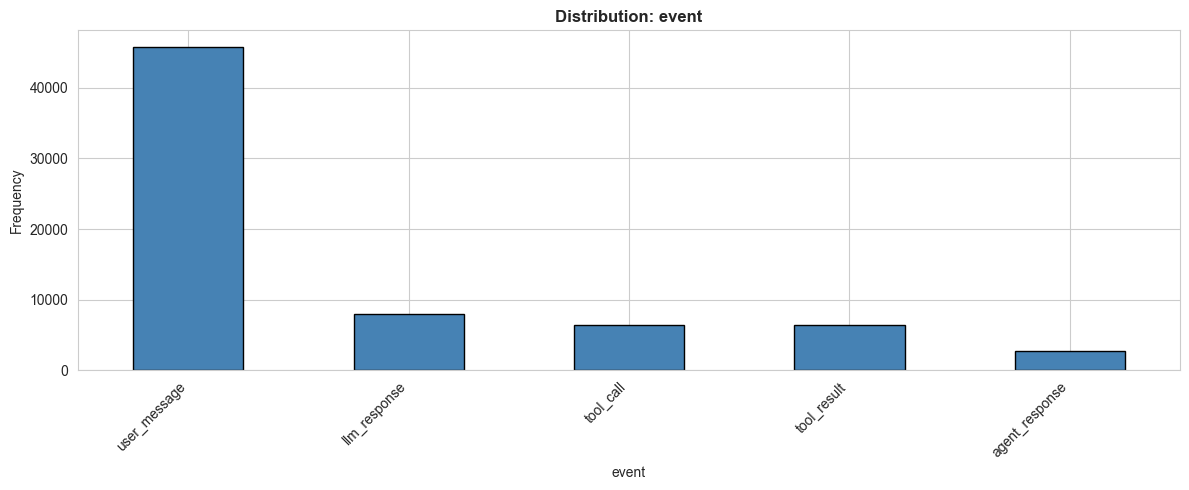


content_hash: Too many unique values (2774) - showing top 20:
content_hash
5f09364bb34154c1    2110
d34c1c4d6ed8901f    1928
63b07f913f16e39f    1925
ae9242a735328859    1850
585b11ba90455102    1850
e6ce345be85c6977    1798
5c4fe02be1eca5ec    1780
34ce4ca5851bc585    1755
50bb79004528bc42    1728
db64c29ff4f52145    1708
9a69c51ffb0db484    1670
386012f6808b056b    1638
8b4575d7b54ee940    1633
b4d280b25eeabf36    1630
be9352c53160cbab    1618
4050e86cd574b9cb    1425
4800a8606337bae0    1420
5a0da30ec3260107    1390
e53919552e8aefd1     320
fd1041759cacf6f7     281
Name: count, dtype: int64


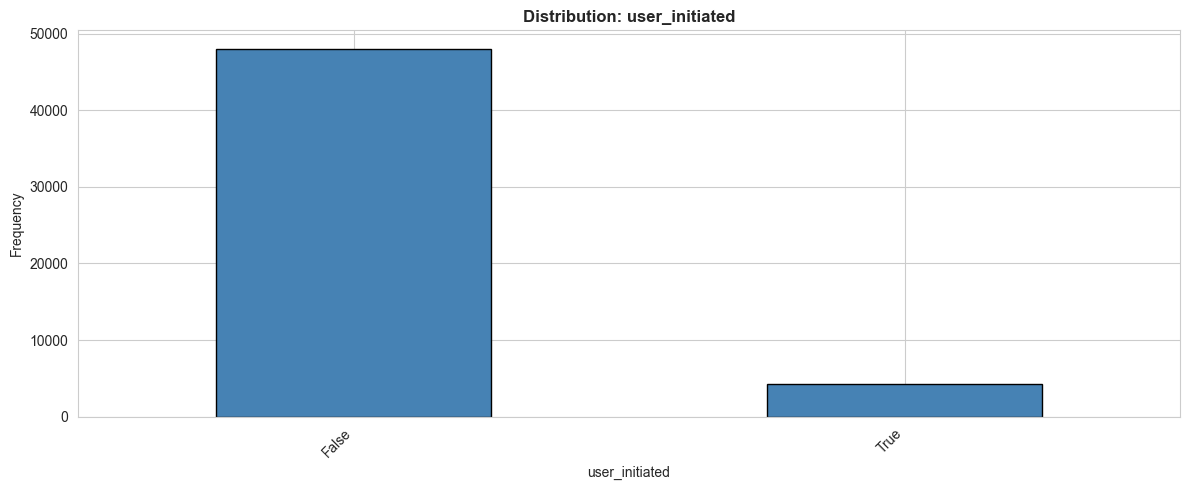

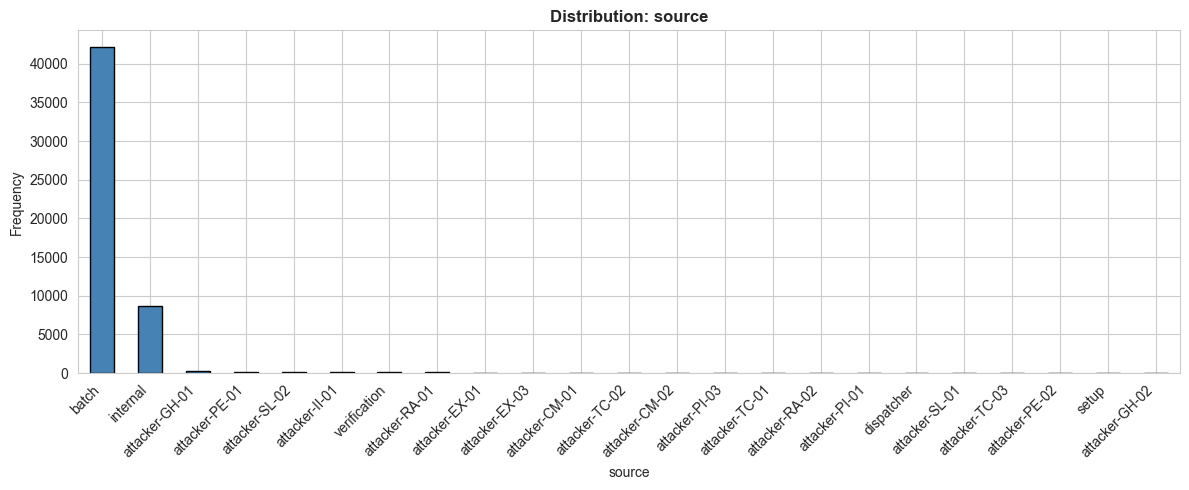

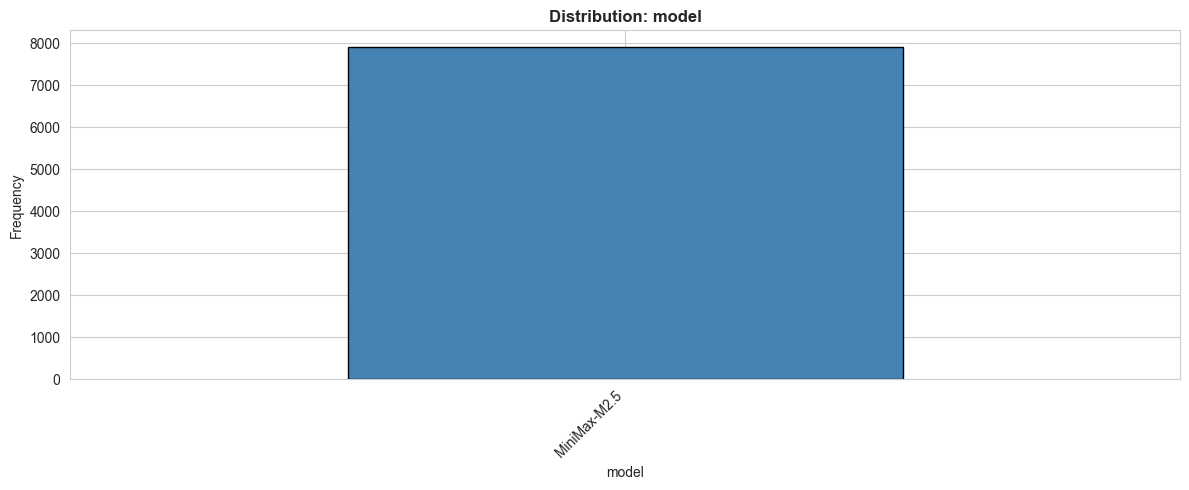

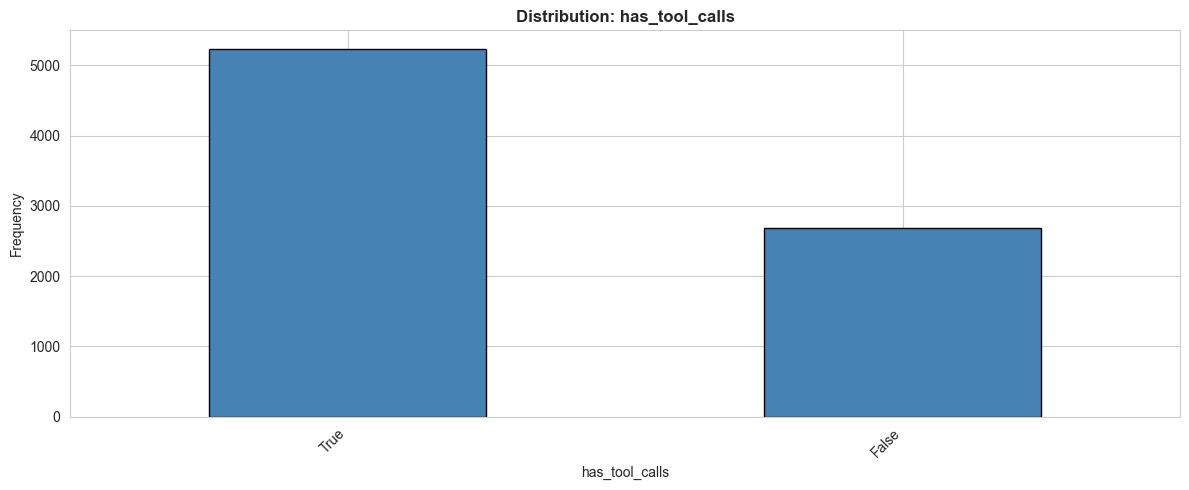

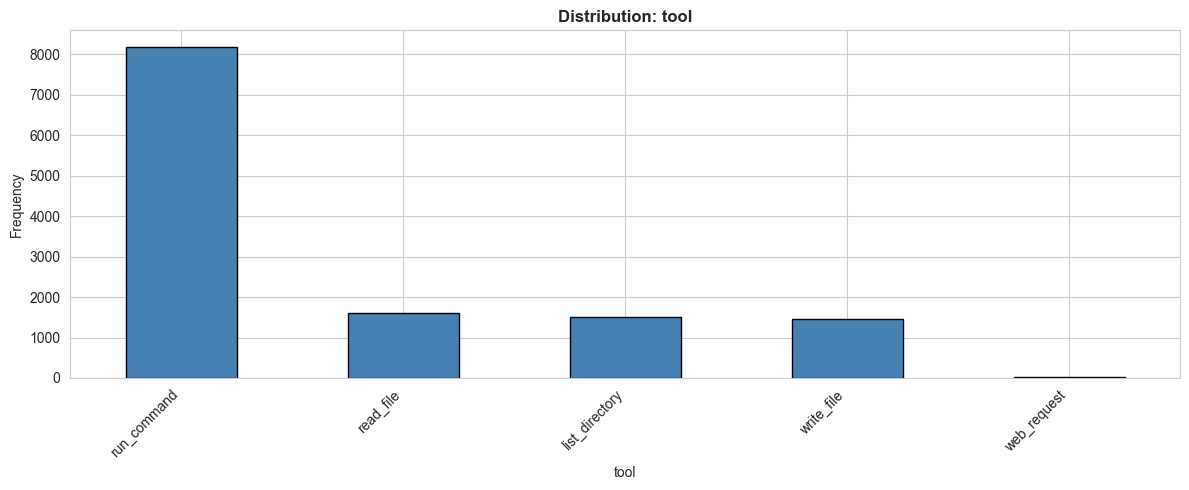


args_hash: Too many unique values (1582) - showing top 20:
args_hash
067e6fda8a03e757    279
dcd628ca13ec5d09    264
ef94be0d05474353    186
379f257c1f25d1ac    179
f8207ec50bc64ac0    131
2ad532687575f185    117
6bc9a748712a94e4    107
810cb25d307b5d2c    101
6ca727a8eb6d78e4    100
58fc7d21c3ceaa9f     97
de12583fa2f1fa16     89
d913de39f7b10df4     88
e6442e0fdc7e269f     86
388c92b1c30c84f4     86
70faa25fcf865f6c     85
247442f5d2366b8f     81
5c481023126811ea     76
e60983fcbac96e39     75
3bccc8e6123bf5b5     74
60575d1dff67ef93     73
Name: count, dtype: int64


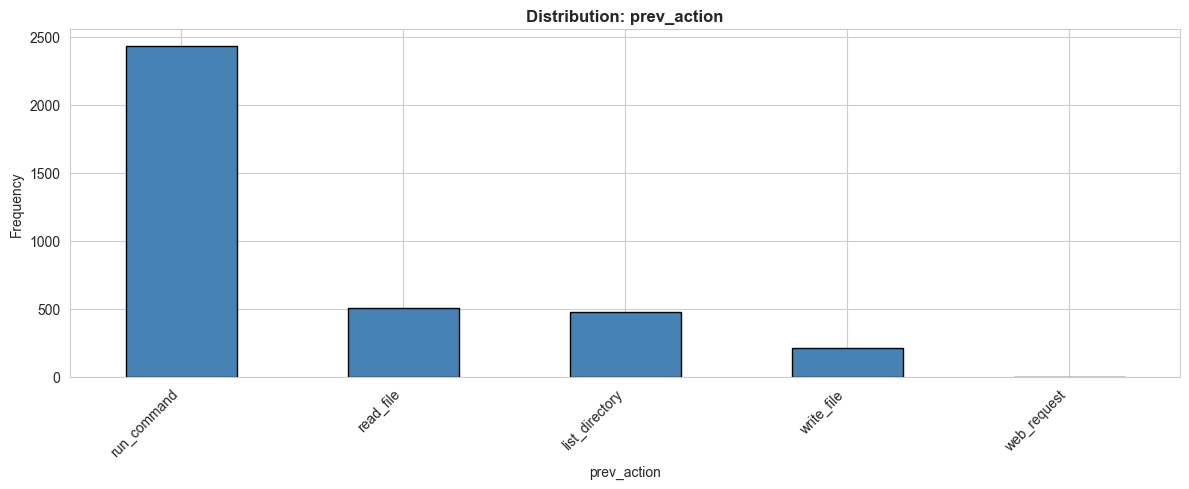


tool_call_id: Too many unique values (6395) - showing top 20:
tool_call_id
call_function_k5c4zxu9etld_1    1
call_function_a430errzrmx3_1    1
call_function_a430errzrmx3_2    1
call_function_ut7gp5kjus9j_1    1
call_function_xijrbv7k6iab_1    1
call_function_5qrzkmwi33yw_1    1
call_function_xvvoi71yz8qr_1    1
call_function_5l3ytsqgx4fn_1    1
call_function_5l3ytsqgx4fn_2    1
call_function_uuh97pj7oidl_1    1
call_function_uuh97pj7oidl_2    1
call_function_uuh97pj7oidl_3    1
call_function_uuh97pj7oidl_4    1
call_function_0dbes4v0jtlw_1    1
call_function_vmmw6ur2zlom_1    1
call_function_psz368jkf84m_1    1
call_function_x2hhxdfz5w5d_1    1
call_function_x2hhxdfz5w5d_2    1
call_function_9zbkm7wniqg6_1    1
call_function_je255elv1nf0_1    1
Name: count, dtype: int64

result_hash: Too many unique values (2335) - showing top 20:
result_hash
none                328
5a3281363c860301    190
8572a3be8508dc98    184
e2cedb654d062870    102
ff312c03f0a5da5e     98
9f29bd2c68c60bac     90


In [9]:
# Identify numeric columns in actions data (excluding agent_id and stream)
actions_numeric_cols = df_actions.select_dtypes(include=[np.number]).columns.tolist()
for col in ['agent_id', 'stream']:
    if col in actions_numeric_cols:
        actions_numeric_cols.remove(col)

print(f"Numeric columns in actions: {actions_numeric_cols}")

# Identify categorical/string columns
actions_cat_cols = df_actions.select_dtypes(include=['object']).columns.tolist()
if 'agent_id' in actions_cat_cols:
    actions_cat_cols.remove('agent_id')

print(f"Categorical columns in actions: {actions_cat_cols}")

# Visualize numeric fields
if actions_numeric_cols:
    fig, axes = plt.subplots(len(actions_numeric_cols), 2, figsize=(14, 5*len(actions_numeric_cols)))
    if len(actions_numeric_cols) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, col in enumerate(actions_numeric_cols):
        # Histogram
        axes[idx, 0].hist(df_actions[col].dropna(), bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
        axes[idx, 0].set_title(f'Histogram: {col}', fontsize=12, fontweight='bold')
        axes[idx, 0].set_xlabel(col)
        axes[idx, 0].set_ylabel('Frequency')
        axes[idx, 0].grid(True, alpha=0.3)
        
        # Box plot  
        df_actions.boxplot(column=col, ax=axes[idx, 1])
        axes[idx, 1].set_title(f'Box Plot: {col}', fontsize=12, fontweight='bold')
        axes[idx, 1].set_ylabel(col)
        axes[idx, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualize categorical fields (excluding stream since it's constant)
cat_cols_to_viz = [col for col in actions_cat_cols if col != 'stream']
if cat_cols_to_viz:
    for col in cat_cols_to_viz:
        value_counts = df_actions[col].value_counts()
        if len(value_counts) <= 30:  # Only show if not too many unique values
            fig, ax = plt.subplots(figsize=(12, 5))
            value_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
            ax.set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
            ax.set_xlabel(col)
            ax.set_ylabel('Frequency')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
        else:
            print(f"\n{col}: Too many unique values ({len(value_counts)}) - showing top 20:")
            print(value_counts.head(20))


## Section 9: Analyze Actions Statistics

Calculate descriptive statistics for each actions field and identify patterns or anomalies in agent behavior.

In [10]:
# Calculate descriptive statistics for numeric actions fields
if actions_numeric_cols:
    print("=" * 80)
    print("ACTIONS NUMERIC FIELD STATISTICS")
    print("=" * 80)
    
    for col in actions_numeric_cols:
        print(f"\n{col.upper()}:")
        print("-" * 40)
        stats = df_actions[col].describe()
        print(stats)
        
        # Additional statistics
        print(f"\nPercentiles:")
        percentiles = df_actions[col].quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
        for perc, val in percentiles.items():
            print(f"  {perc*100:.0f}%: {val:.2f}")
        
        # Outlier detection
        Q1 = df_actions[col].quantile(0.25)
        Q3 = df_actions[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df_actions[(df_actions[col] < lower_bound) | (df_actions[col] > upper_bound)]
        print(f"\nOutliers (IQR method): {len(outliers)} ({len(outliers)/len(df_actions)*100:.2f}%)")

# Categorical field analysis
if actions_cat_cols:
    print("\n\n" + "=" * 80)
    print("ACTIONS CATEGORICAL FIELD STATISTICS")
    print("=" * 80)
    
    for col in actions_cat_cols:
        print(f"\n{col.upper()}:")
        print("-" * 40)
        value_counts = df_actions[col].value_counts()
        print(f"Unique values: {df_actions[col].nunique()}")
        print(f"Top 10 values:\n{value_counts.head(10)}")

# Action counts by agent
print("\n\n" + "=" * 80)
print("ACTION COUNTS BY AGENT")
print("=" * 80)
agent_action_counts = df_actions.groupby('agent_id').size()
print(agent_action_counts)
print(f"\nTotal: {agent_action_counts.sum()}")
print(f"Mean: {agent_action_counts.mean():.2f}")
print(f"Std: {agent_action_counts.std():.2f}")

ACTIONS NUMERIC FIELD STATISTICS

TOKENS_IN:
----------------------------------------
count    7915.000000
mean      739.669488
std       453.752512
min       427.000000
25%       438.000000
50%       545.000000
75%       851.000000
max      4053.000000
Name: tokens_in, dtype: float64

Percentiles:
  25%: 438.00
  50%: 545.00
  75%: 851.00
  90%: 1350.00
  95%: 1693.20
  99%: 2528.32

Outliers (IQR method): 567 (0.82%)

TOKENS_OUT:
----------------------------------------
count    7915.000000
mean      170.068604
std       162.704184
min        32.000000
25%        66.000000
50%       104.000000
75%       221.000000
max      1024.000000
Name: tokens_out, dtype: float64

Percentiles:
  25%: 66.00
  50%: 104.00
  75%: 221.00
  90%: 360.00
  95%: 460.30
  99%: 928.46

Outliers (IQR method): 409 (0.59%)

LATENCY:
----------------------------------------
count    14310.000000
mean         4.081471
std          6.413337
min          0.000000
25%          0.002000
50%          2.663000
75%   

## Section 11: Attack Pattern Analysis

Analyze attack patterns from attacker agents in the prompts. Examine events, sources, and attack characteristics across different time windows.


ATTACK PATTERN ANALYSIS


Attack Sources in Actions:
----------------------------------------
source
batch             42216
internal           8722
attacker-GH-01      249
attacker-PE-01      185
attacker-SL-02      138
attacker-II-01      127
verification        117
attacker-RA-01       90
attacker-EX-01       47
attacker-EX-03       45
attacker-CM-01       35
attacker-TC-02       33
attacker-CM-02       33
attacker-PI-03       28
attacker-TC-01       28
attacker-RA-02       25
attacker-PI-01       23
dispatcher           21
attacker-SL-01       16
attacker-TC-03       16
attacker-PE-02       14
setup                 8
attacker-GH-02        5
Name: count, dtype: int64

Total attacker-initiated actions: 1137

Attacker actions by source:
source
attacker-GH-01    249
attacker-PE-01    185
attacker-SL-02    138
attacker-II-01    127
attacker-RA-01     90
attacker-EX-01     47
attacker-EX-03     45
attacker-CM-01     35
attacker-TC-02     33
attacker-CM-02     33
attacker-TC-01     28
att

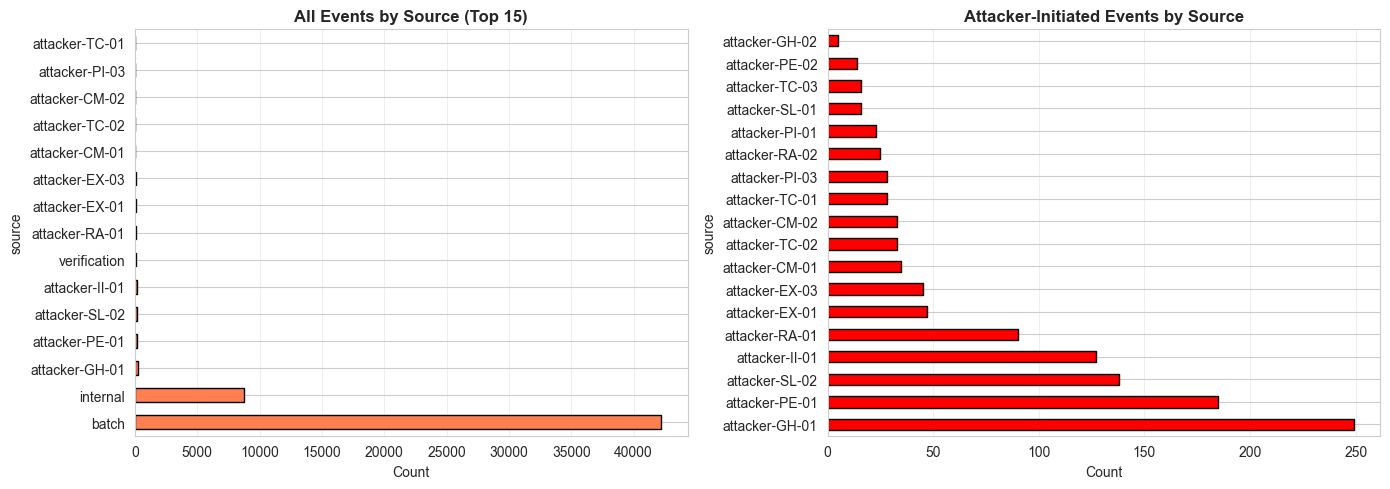

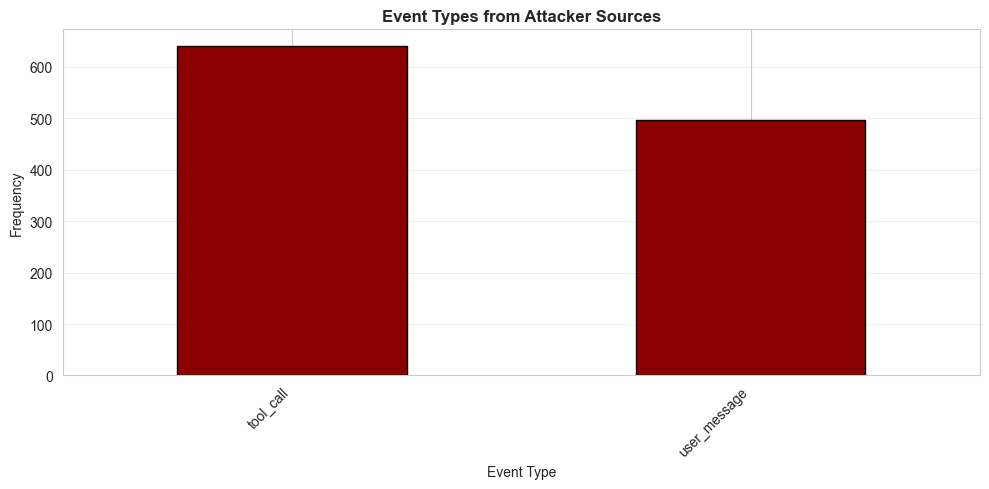

In [11]:
# Convert timestamp to datetime for time-based analysis
df_actions['timestamp_dt'] = pd.to_datetime(df_actions['timestamp'])
df_telemetry['timestamp_dt'] = pd.to_datetime(df_telemetry['timestamp'])

# Filter for attack patterns (events from attackers)
print("=" * 80)
print("ATTACK PATTERN ANALYSIS")
print("=" * 80)

# Identify attack sources
print("\n\nAttack Sources in Actions:")
print("-" * 40)
if 'source' in df_actions.columns:
    attack_sources = df_actions['source'].value_counts()
    print(attack_sources)
    
    # Attacks per source
    attacker_actions = df_actions[df_actions['source'].str.contains('attacker', case=False, na=False)]
    print(f"\nTotal attacker-initiated actions: {len(attacker_actions)}")
    print(f"\nAttacker actions by source:")
    print(attacker_actions['source'].value_counts())

# Analyze event types from attackers
print("\n\nEvent Types from Attackers:")
print("-" * 40)
if len(attacker_actions) > 0:
    print(attacker_actions['event'].value_counts())

# Analyze user_initiated patterns from attackers
print("\n\nUser-Initiated Patterns from Attackers:")
print("-" * 40)
if 'user_initiated' in attacker_actions.columns:
    print(attacker_actions['user_initiated'].value_counts())

# Visualize attack sources
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'source' in df_actions.columns:
    # All sources
    source_counts = df_actions['source'].value_counts().head(15)
    source_counts.plot(kind='barh', ax=axes[0], color='coral', edgecolor='black')
    axes[0].set_title('All Events by Source (Top 15)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Count')
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Attack sources only
    attacker_sources = attacker_actions['source'].value_counts()
    attacker_sources.plot(kind='barh', ax=axes[1], color='red', edgecolor='black')
    axes[1].set_title('Attacker-Initiated Events by Source', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Count')
    axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Event type distribution from attackers
if len(attacker_actions) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    event_counts = attacker_actions['event'].value_counts()
    event_counts.plot(kind='bar', ax=ax, color='darkred', edgecolor='black')
    ax.set_title('Event Types from Attacker Sources', fontsize=12, fontweight='bold')
    ax.set_xlabel('Event Type')
    ax.set_ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


## Section 12: Time-Window Correlation Analysis

Correlate attack patterns with telemetry metrics within the same time windows to identify relationships between attacks and resource usage.


In [12]:
# Define time windows for correlation analysis (5-second windows)
print("=" * 80)
print("TIME-WINDOW CORRELATION ANALYSIS")
print("=" * 80)

# Create 5-second windows
df_actions['time_window'] = df_actions['timestamp_dt'].dt.floor('5S')
df_telemetry['time_window'] = df_telemetry['timestamp_dt'].dt.floor('5S')

# Count actions per time window per agent
actions_per_window = df_actions.groupby(['time_window', 'agent_id']).size().reset_index(name='action_count')
attacker_events_per_window = df_actions[df_actions['source'].str.contains('attacker', case=False, na=False)].groupby(
    ['time_window', 'agent_id']
).size().reset_index(name='attacker_event_count')

print("\nActions per time window (sample):")
print(actions_per_window.head(10))

TIME-WINDOW CORRELATION ANALYSIS

Actions per time window (sample):
                time_window  agent_id  action_count
0 2026-03-15 12:13:45+00:00         1             2
1 2026-03-15 12:13:45+00:00         2             2
2 2026-03-15 12:13:45+00:00         3             2
3 2026-03-15 12:13:45+00:00         4             2
4 2026-03-15 12:13:45+00:00         5             2
5 2026-03-15 12:13:50+00:00         1             6
6 2026-03-15 12:13:50+00:00         2             6
7 2026-03-15 12:13:50+00:00         3             6
8 2026-03-15 12:13:50+00:00         4             6
9 2026-03-15 12:13:50+00:00         5             8


In [13]:
print("\n\nAttacker events per time window (sample):")
print(attacker_events_per_window.head(10))



Attacker events per time window (sample):
                time_window  agent_id  attacker_event_count
0 2026-03-15 12:13:45+00:00         1                     1
1 2026-03-15 12:13:45+00:00         2                     1
2 2026-03-15 12:13:45+00:00         3                     1
3 2026-03-15 12:13:45+00:00         4                     1
4 2026-03-15 12:13:45+00:00         5                     1
5 2026-03-15 12:14:00+00:00         1                     1
6 2026-03-15 12:14:00+00:00         2                     1
7 2026-03-15 12:14:00+00:00         3                     1
8 2026-03-15 12:14:00+00:00         4                     1
9 2026-03-15 12:14:00+00:00         5                     1


In [14]:
# For each agent, find telemetry during times of attacks
print("\n\n" + "=" * 80)
print("CORRELATING ATTACKS WITH TELEMETRY METRICS")
print("=" * 80)

for agent_num in sorted(df_actions['agent_id'].unique())[:5]:  # First 5 agents for detailed analysis
    print(f"\n\nAgent {agent_num}:")
    print("-" * 60)
    
    # Get windows with attacks from attacker sources
    agent_attacker_events = df_actions[
        (df_actions['agent_id'] == agent_num) & 
        (df_actions['source'].str.contains('attacker', case=False, na=False))
    ]
    
    if len(agent_attacker_events) > 0:
        attack_windows = agent_attacker_events['time_window'].unique()
        print(f"Time windows with attacker events: {len(attack_windows)}")
        print(f"Total attacker events: {len(agent_attacker_events)}")
        
        # Get telemetry for this agent during attack windows
        agent_telemetry = df_telemetry[df_telemetry['agent_id'] == agent_num]
        telemetry_during_attacks = agent_telemetry[agent_telemetry['time_window'].isin(attack_windows)]
        
        if len(telemetry_during_attacks) > 0:
            print(f"\nTelemetry records during attacks: {len(telemetry_during_attacks)}")
            
            # Extract memory and CPU info
            if 'memory' in agent_telemetry.columns and len(agent_telemetry) > 0:
                print("\nMemory usage during attacks (sample stats):")
                try:
                    # Handle nested dict structure
                    memory_samples = telemetry_during_attacks['memory'].head(3)
                    print(memory_samples)
                except:
                    pass



CORRELATING ATTACKS WITH TELEMETRY METRICS


Agent 1:
------------------------------------------------------------
Time windows with attacker events: 158
Total attacker events: 199

Telemetry records during attacks: 154

Memory usage during attacks (sample stats):
1     {'total_kb': 8136552, 'available_kb': 5821016,...
13    {'total_kb': 8136552, 'available_kb': 6942060,...
25    {'total_kb': 8136552, 'available_kb': 6950820,...
Name: memory, dtype: object


Agent 2:
------------------------------------------------------------
Time windows with attacker events: 158
Total attacker events: 200

Telemetry records during attacks: 156

Memory usage during attacks (sample stats):
2981    {'total_kb': 8136552, 'available_kb': 5824080,...
2982    {'total_kb': 8136552, 'available_kb': 6659820,...
2993    {'total_kb': 8136552, 'available_kb': 6942060,...
Name: memory, dtype: object


Agent 3:
------------------------------------------------------------
Time windows with attacker events: 147
To



ATTACK TARGETING SUMMARY

Attack events per agent:
agent_id
2     200
1     199
5     182
3     177
4     177
8      29
7      27
6      26
10     21
13     19
12     17
14     17
9      16
11     16
15     14
dtype: int64


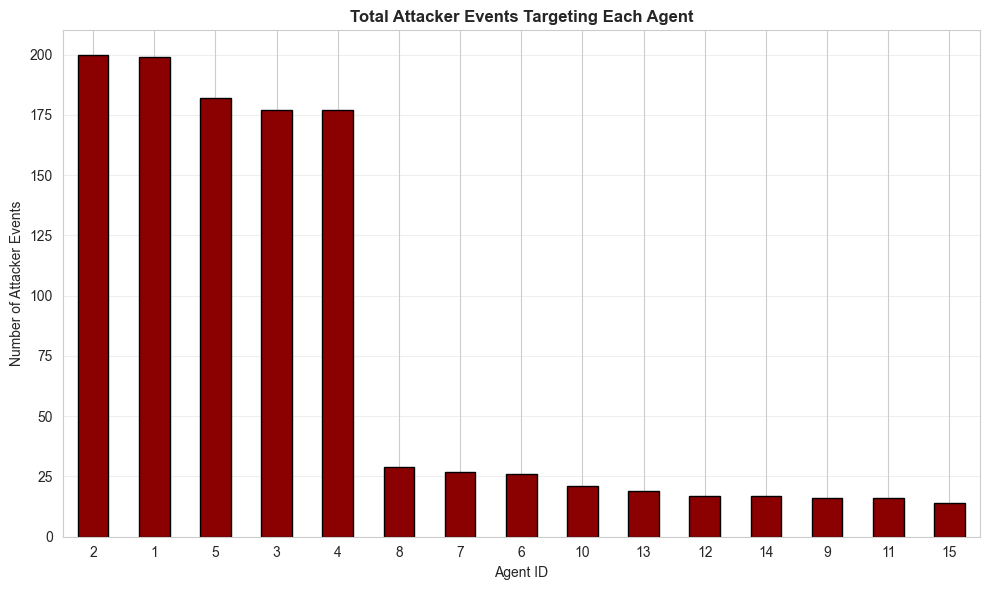

In [15]:
# Summary: Which agents were most targeted by attackers
print("\n\n" + "=" * 80)
print("ATTACK TARGETING SUMMARY")
print("=" * 80)

agent_attack_counts = df_actions[
    df_actions['source'].str.contains('attacker', case=False, na=False)
].groupby('agent_id').size().sort_values(ascending=False)

print("\nAttack events per agent:")
print(agent_attack_counts)

fig, ax = plt.subplots(figsize=(10, 6))
agent_attack_counts.plot(kind='bar', ax=ax, color='darkred', edgecolor='black')
ax.set_title('Total Attacker Events Targeting Each Agent', fontsize=12, fontweight='bold')
ax.set_xlabel('Agent ID')
ax.set_ylabel('Number of Attacker Events')
plt.xticks(rotation=0)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## Section 13: Telemetry Comparison - Attacks vs Non-Attacks

Compare telemetry metrics during periods with attacks vs periods without attacks to understand how attacks impact system resources (CPU, memory, I/O).


In [16]:
print("=" * 80)
print("TELEMETRY COMPARISON: ATTACKS VS NON-ATTACKS")
print("=" * 80)

# Build attack windows per agent
attack_time_windows_by_agent = {}

for agent_num in sorted(df_actions['agent_id'].unique()):
    agent_attacker_events = df_actions[
        (df_actions['agent_id'] == agent_num) &
        (df_actions['source'].str.contains('attacker', case=False, na=False))
    ]

    attack_time_windows_by_agent[agent_num] = (
        set(agent_attacker_events['time_window'].unique())
        if len(agent_attacker_events) > 0 else set()
    )

# Label telemetry
df_telemetry['is_during_attack'] = df_telemetry.apply(
    lambda row: row['time_window']
    in attack_time_windows_by_agent.get(row['agent_id'], set()),
    axis=1
)

print(df_telemetry['is_during_attack'].value_counts())

TELEMETRY COMPARISON: ATTACKS VS NON-ATTACKS
is_during_attack
False    39484
True       919
Name: count, dtype: int64


In [17]:
print("\nExtracting nested telemetry fields...")

extracted_data = {
    'cpu_usage_pct': [],
    'total_jiffies': [],
    'idle_jiffies': [],
    'memory_total_kb': [],
    'memory_available_kb': [],
    'memory_used_kb': [],
    'memory_usage_pct': [],
    'sectors_read': [],
    'sectors_written': [],
    'read_sectors_per_sec': [],
    'write_sectors_per_sec': []
}

for idx, row in df_telemetry.iterrows():

    # ---- CPU ----
    try:
        cpu_dict = row['cpu'] if isinstance(row['cpu'], dict) else json.loads(row['cpu'])
        extracted_data['cpu_usage_pct'].append(cpu_dict.get('cpu_usage_pct', np.nan))
        extracted_data['total_jiffies'].append(cpu_dict.get('total_jiffies', np.nan))
        extracted_data['idle_jiffies'].append(cpu_dict.get('idle_jiffies', np.nan))
    except:
        extracted_data['cpu_usage_pct'].append(np.nan)
        extracted_data['total_jiffies'].append(np.nan)
        extracted_data['idle_jiffies'].append(np.nan)

    # ---- MEMORY ----
    try:
        mem_dict = row['memory'] if isinstance(row['memory'], dict) else json.loads(row['memory'])
        extracted_data['memory_total_kb'].append(mem_dict.get('total_kb', np.nan))
        extracted_data['memory_available_kb'].append(mem_dict.get('available_kb', np.nan))
        extracted_data['memory_used_kb'].append(mem_dict.get('used_kb', np.nan))
        extracted_data['memory_usage_pct'].append(mem_dict.get('usage_pct', np.nan))
    except:
        extracted_data['memory_total_kb'].append(np.nan)
        extracted_data['memory_available_kb'].append(np.nan)
        extracted_data['memory_used_kb'].append(np.nan)
        extracted_data['memory_usage_pct'].append(np.nan)

    # ---- FILE I/O ----
    try:
        io_dict = row['file_io'] if isinstance(row['file_io'], dict) else json.loads(row['file_io'])
        extracted_data['sectors_read'].append(io_dict.get('sectors_read', np.nan))
        extracted_data['sectors_written'].append(io_dict.get('sectors_written', np.nan))
        extracted_data['read_sectors_per_sec'].append(io_dict.get('read_sectors_per_sec', np.nan))
        extracted_data['write_sectors_per_sec'].append(io_dict.get('write_sectors_per_sec', np.nan))
    except:
        extracted_data['sectors_read'].append(np.nan)
        extracted_data['sectors_written'].append(np.nan)
        extracted_data['read_sectors_per_sec'].append(np.nan)
        extracted_data['write_sectors_per_sec'].append(np.nan)

# attach to df
for k, v in extracted_data.items():
    df_telemetry[k] = v


Extracting nested telemetry fields...


In [18]:
comparison_metrics = [
    'cpu_usage_pct',
    'memory_used_kb',
    'memory_usage_pct',
    'sectors_read',
    'sectors_written',
    'read_sectors_per_sec',
    'write_sectors_per_sec'
]

available_metrics = [
    m for m in comparison_metrics
    if df_telemetry[m].notna().sum() > 0
]

print("Available metrics:", available_metrics)

Available metrics: ['cpu_usage_pct', 'memory_used_kb', 'memory_usage_pct', 'sectors_read', 'sectors_written', 'read_sectors_per_sec', 'write_sectors_per_sec']


In [19]:
print("\n" + "=" * 80)
print("STATISTICAL COMPARISON")
print("=" * 80)

from scipy import stats

for metric in available_metrics:

    print(f"\n{metric}")
    print("-" * 50)

    attack = df_telemetry[df_telemetry['is_during_attack']][metric].dropna()
    normal = df_telemetry[~df_telemetry['is_during_attack']][metric].dropna()

    if len(attack) == 0 or len(normal) == 0:
        continue

    print("Attack mean:", attack.mean())
    print("Normal mean:", normal.mean())

    if normal.mean() > 0:
        print("Percent diff:",
              ((attack.mean() - normal.mean()) / normal.mean()) * 100)

    t_stat, p_val = stats.ttest_ind(attack, normal)
    print("p-value:", p_val)


STATISTICAL COMPARISON

cpu_usage_pct
--------------------------------------------------
Attack mean: 9.43322089227421
Normal mean: 6.793784208392459
Percent diff: 38.85075832436976
p-value: 2.9885754766797823e-13

memory_used_kb
--------------------------------------------------
Attack mean: 1506357.3492927095
Normal mean: 1663489.905480701
Percent diff: -9.4459579027373
p-value: 4.96653632645322e-16

memory_usage_pct
--------------------------------------------------
Attack mean: 18.513547334058757
Normal mean: 20.44459426603181
Percent diff: -9.445269037113837
p-value: 4.991871017726594e-16

sectors_read
--------------------------------------------------
Attack mean: 64132971.16104461
Normal mean: 350074655.038294
Percent diff: -81.68020156899699
p-value: 0.0

sectors_written
--------------------------------------------------
Attack mean: 5815450.613710555
Normal mean: 9163295.620707123
Percent diff: -36.53538143450421
p-value: 0.0

read_sectors_per_sec
----------------------------

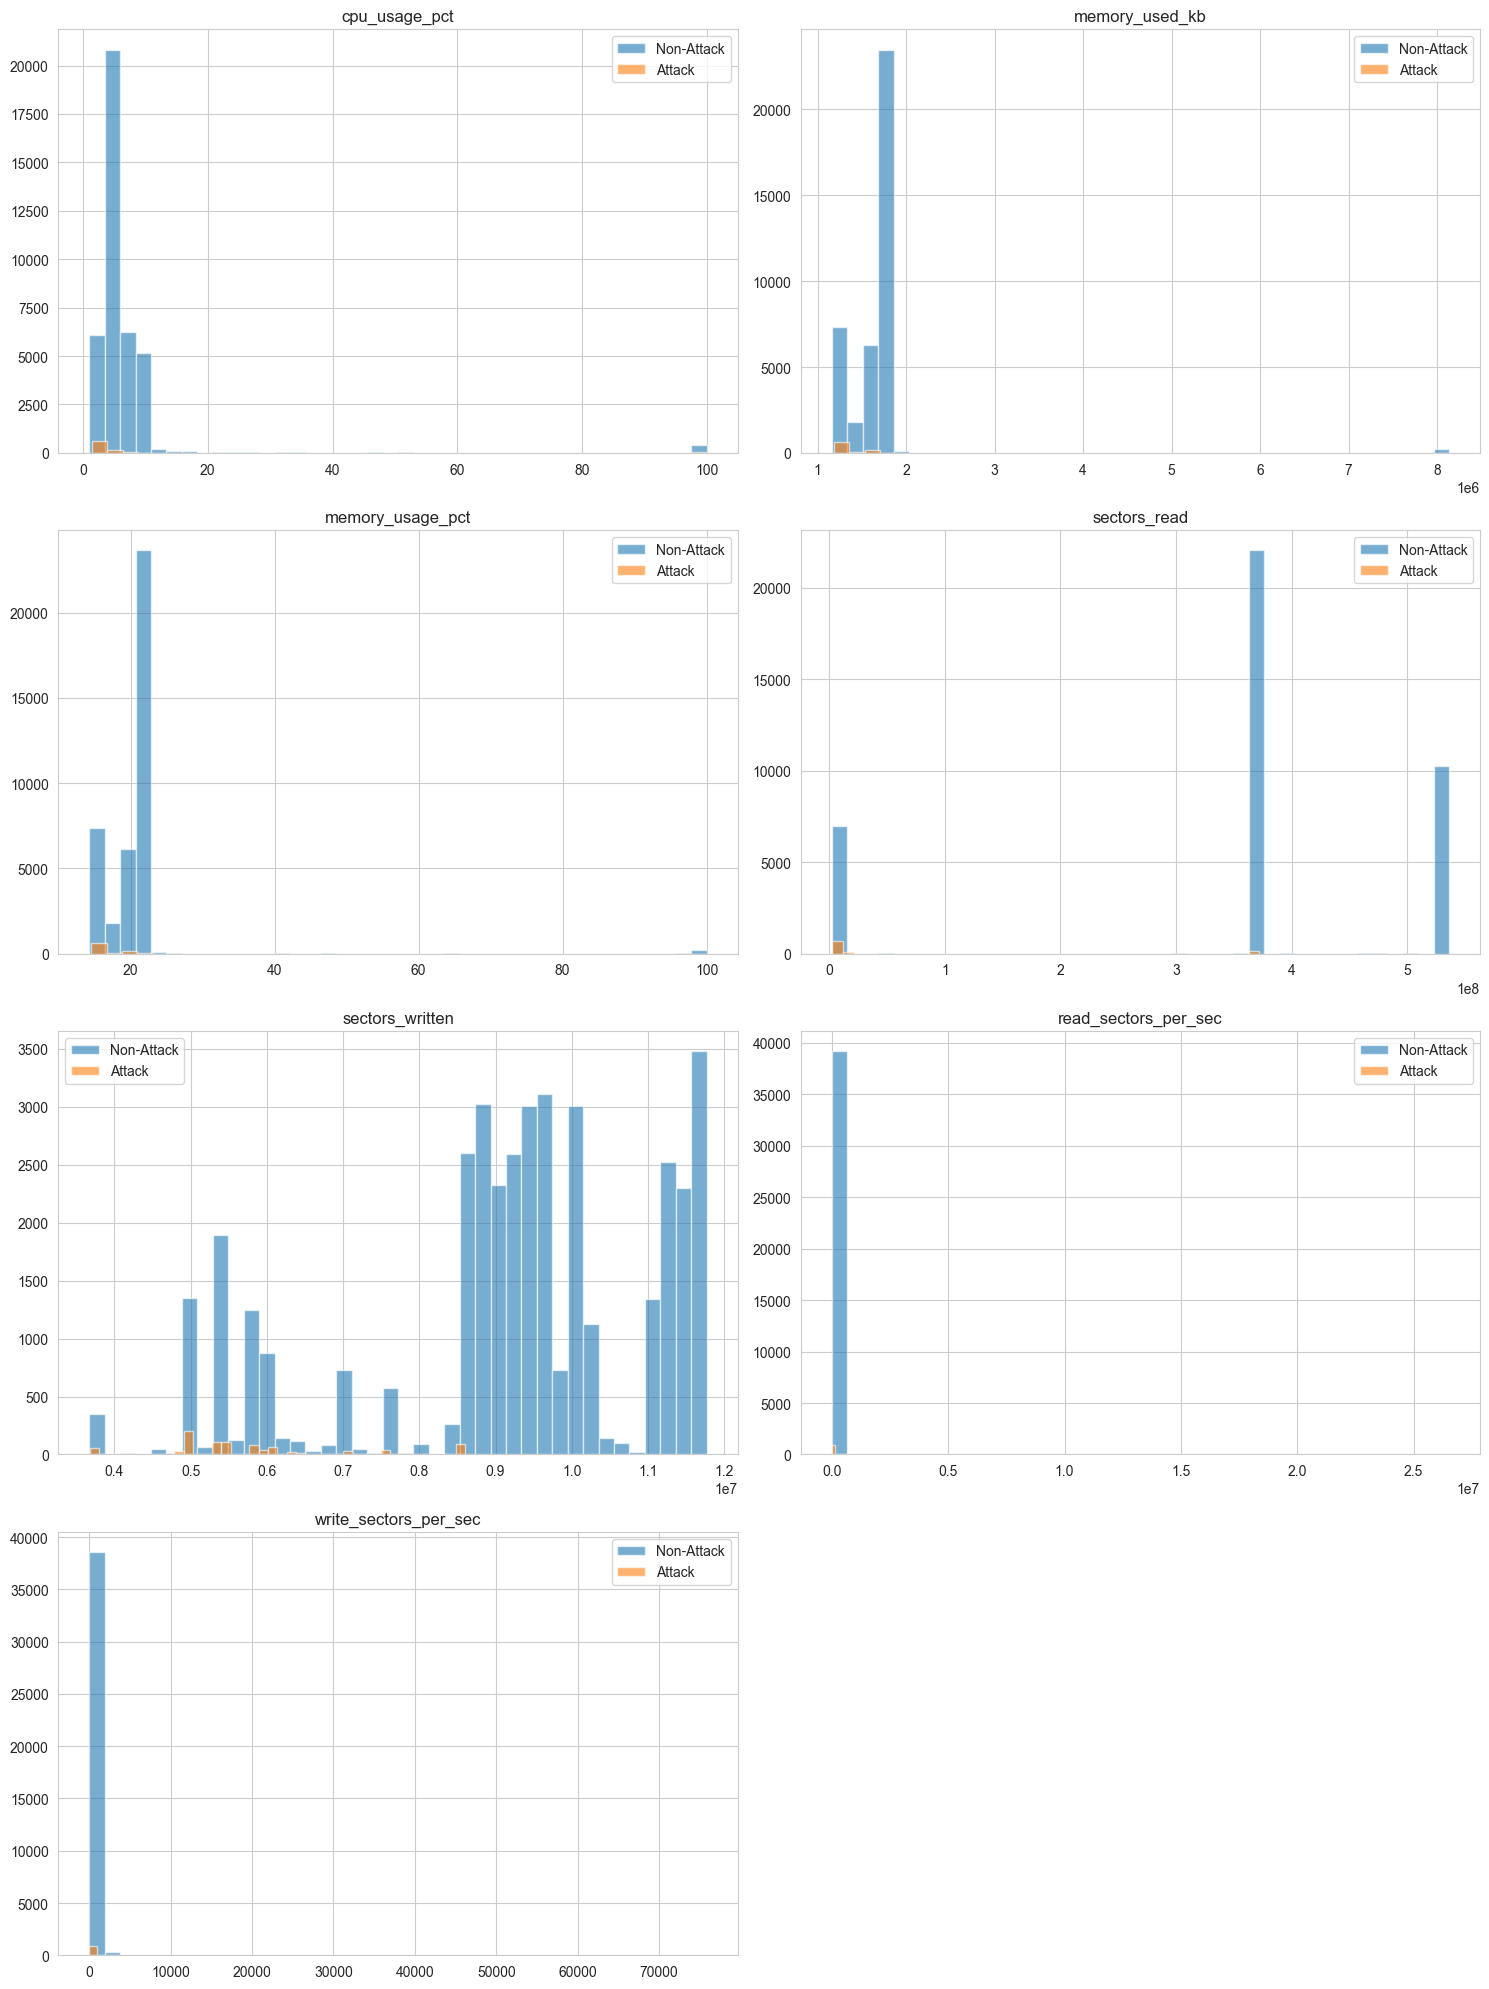

In [20]:
n_metrics = len(available_metrics)

fig, axes = plt.subplots(
    (n_metrics + 1)//2, 2,
    figsize=(15, 5*((n_metrics + 1)//2))
)

axes = axes.flatten()

for i, metric in enumerate(available_metrics):

    ax = axes[i]

    attack = df_telemetry[df_telemetry['is_during_attack']][metric].dropna()
    normal = df_telemetry[~df_telemetry['is_during_attack']][metric].dropna()

    ax.hist(normal, bins=40, alpha=0.6, label="Non-Attack")
    ax.hist(attack, bins=40, alpha=0.6, label="Attack")

    ax.set_title(metric)
    ax.legend()

for j in range(len(available_metrics), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

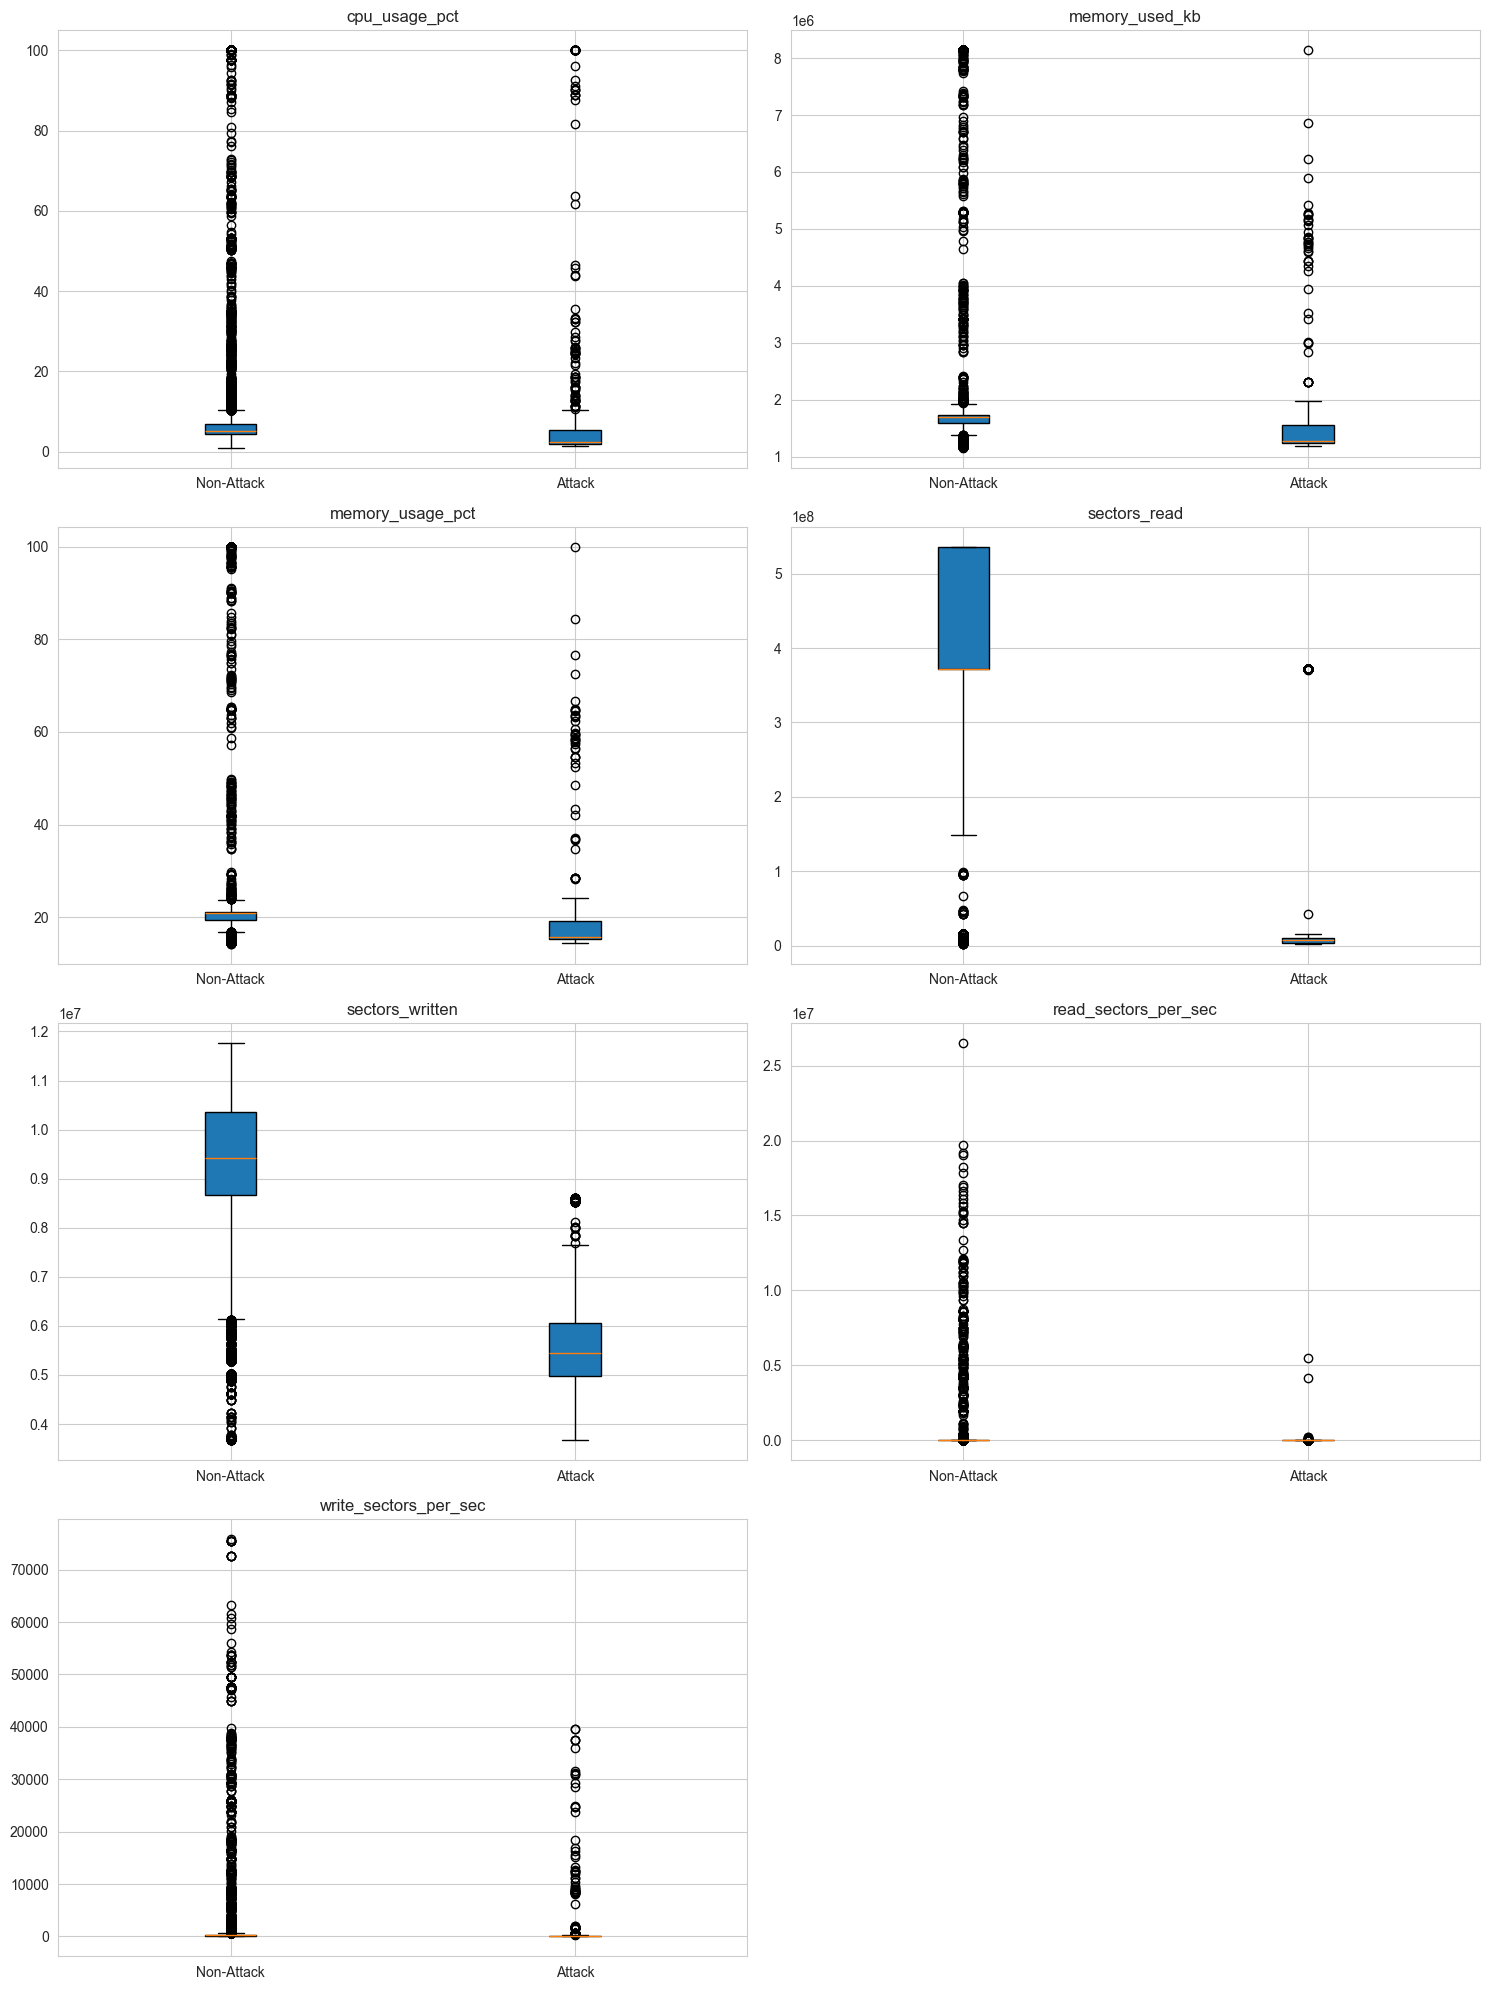

In [21]:
fig, axes = plt.subplots(
    (n_metrics + 1)//2, 2,
    figsize=(15, 5*((n_metrics + 1)//2))
)

axes = axes.flatten()

for i, metric in enumerate(available_metrics):

    ax = axes[i]

    attack = df_telemetry[df_telemetry['is_during_attack']][metric].dropna()
    normal = df_telemetry[~df_telemetry['is_during_attack']][metric].dropna()

    ax.boxplot([normal, attack],
               labels=['Non-Attack', 'Attack'],
               patch_artist=True)

    ax.set_title(metric)

for j in range(len(available_metrics), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [22]:
print("\n" + "=" * 80)
print("PER-AGENT COMPARISON")
print("=" * 80)

for agent in sorted(df_telemetry['agent_id'].unique()):

    data = df_telemetry[df_telemetry['agent_id'] == agent]

    attack = data[data['is_during_attack']]
    normal = data[~data['is_during_attack']]

    print(f"\nAgent {agent}")
    print("Attack samples:", len(attack))
    print("Normal samples:", len(normal))

    for metric in available_metrics:
        if len(attack) > 0 and len(normal) > 0:
            a = attack[metric].mean()
            n = normal[metric].mean()

            if n > 0:
                print(f"{metric}: {((a-n)/n)*100:+.1f}%")


PER-AGENT COMPARISON

Agent 1
Attack samples: 154
Normal samples: 2826
cpu_usage_pct: +34.1%
memory_used_kb: -7.8%
memory_usage_pct: -7.8%
sectors_read: -87.0%
sectors_written: -32.2%
read_sectors_per_sec: -24.0%
write_sectors_per_sec: +3.0%

Agent 2
Attack samples: 156
Normal samples: 2825
cpu_usage_pct: +17.5%
memory_used_kb: -10.0%
memory_usage_pct: -10.0%
sectors_read: -88.0%
sectors_written: -31.7%
read_sectors_per_sec: -95.3%
write_sectors_per_sec: -55.3%

Agent 3
Attack samples: 144
Normal samples: 2837
cpu_usage_pct: +55.7%
memory_used_kb: -8.0%
memory_usage_pct: -8.0%
sectors_read: -86.2%
sectors_written: -32.1%
read_sectors_per_sec: -96.7%
write_sectors_per_sec: +123.6%

Agent 4
Attack samples: 144
Normal samples: 2838
cpu_usage_pct: +42.1%
memory_used_kb: -9.2%
memory_usage_pct: -9.2%
sectors_read: -87.1%
sectors_written: -32.0%
read_sectors_per_sec: -95.5%
write_sectors_per_sec: +58.3%

Agent 5
Attack samples: 147
Normal samples: 2834
cpu_usage_pct: +63.2%
memory_used_kb: 

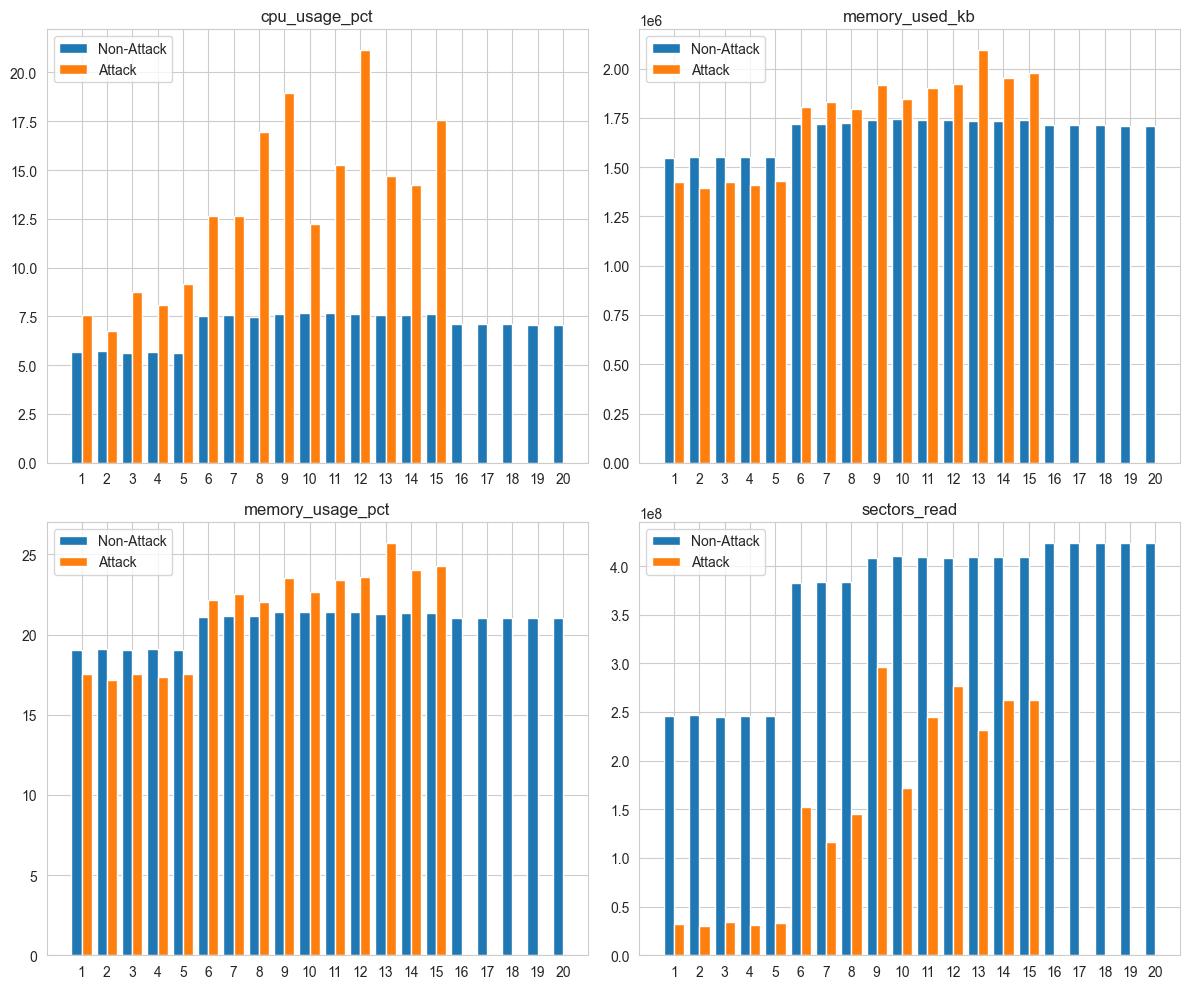

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

agents = sorted(df_telemetry['agent_id'].unique())

for i, metric in enumerate(available_metrics[:4]):

    ax = axes[i]

    attack_means = []
    normal_means = []

    for agent in agents:
        data = df_telemetry[df_telemetry['agent_id'] == agent]

        attack_means.append(data[data['is_during_attack']][metric].mean())
        normal_means.append(data[~data['is_during_attack']][metric].mean())

    x = np.arange(len(agents))

    ax.bar(x-0.2, normal_means, 0.4, label="Non-Attack")
    ax.bar(x+0.2, attack_means, 0.4, label="Attack")

    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(agents)
    ax.legend()

plt.tight_layout()
plt.show()